In [ ]:
!pip -q install lightgbm joblib scikit-learn==1.8.0 pandas numpy
from google.colab import drive
drive.mount("/content/drive")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 96.1 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
import sklearn
print(sklearn.__version__)

1.8.0


# **Top-P 방식으로 운영할 때 만든 모델**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.impute import SimpleImputer
import lightgbm as lgb

# -------------------------
# 0) PATHS / SETTINGS
# -------------------------  # 업로드한 파일 경로로 수정
LABEL_COL = "y_down_6h"
TIME_COL = "event_at"
CSV_PATH = "/content/drive/MyDrive/KT에이블스쿨/빅프로젝트/train_csv/train_down6h_v3.csv"
SEED = 42
TEST_FRACTION = 0.2        # 마지막 20% 시간을 테스트로 사용
GAP_HOURS = 6             # 정보 누설/근접 상관 완화용 시간 갭(없애려면 0)
TOPK_LIST = [50,100,200,500,1000]

# 누설/라벨구성 관련 컬럼(항상 제외 권장)
LEAK_COLS = {
    "started_down_next6h",
    "down_minutes_next6h",
    # precondition을 피처로 넣고 싶으면 normal_ratio_prev6h는 빼지 말고 아래에서 제거
    "normal_ratio_prev6h",
}

# -------------------------
# 1) LOAD
# -------------------------
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df["charger_key"] = df["statId"].astype(str) + "_" + df["chgerId"].astype(str)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce").astype(int)

# 시간 정렬 + 결측 제거
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)

print("rows:", len(df), "chargers:", df["charger_key"].nunique(), "pos_rate:", df[LABEL_COL].mean())
print("time span:", df[TIME_COL].min(), "~", df[TIME_COL].max())

# -------------------------
# 2) TIME SPLIT (chronological)
# -------------------------
t_split = df[TIME_COL].quantile(1 - TEST_FRACTION)
t_gap = pd.Timedelta(hours=float(GAP_HOURS))

train_df = df[df[TIME_COL] <= (t_split - t_gap)].copy()
test_df  = df[df[TIME_COL] >  t_split].copy()

print("\n==== TIME SPLIT ====")
print("split_time:", t_split, "gap_hours:", GAP_HOURS)
print("train rows:", len(train_df), "test rows:", len(test_df))
print("train pos_rate:", train_df[LABEL_COL].mean(), "test pos_rate:", test_df[LABEL_COL].mean())
print("train time:", train_df[TIME_COL].min(), "~", train_df[TIME_COL].max())
print("test  time:", test_df[TIME_COL].min(), "~", test_df[TIME_COL].max())

# (선택) train/test에 같은 charger가 섞이는 걸 더 엄격히 막고 싶으면 아래를 켜도 됨
# 단, 데이터가 더 줄어들 수 있음
STRICT_NO_CHARGER_OVERLAP = False
if STRICT_NO_CHARGER_OVERLAP:
    train_ch = set(train_df["charger_key"].unique())
    test_df = test_df[~test_df["charger_key"].isin(train_ch)].copy()
    print("after strict no-overlap | test rows:", len(test_df), "test chargers:", test_df["charger_key"].nunique())

# -------------------------
# 3) FEATURES
# -------------------------
drop_cols = {LABEL_COL, TIME_COL, "statId", "chgerId", "busiId", "charger_key"} | LEAK_COLS
feature_cols = [c for c in train_df.columns
                if c not in drop_cols and pd.api.types.is_numeric_dtype(train_df[c])]

print("\n#features:", len(feature_cols))
print("sample features:", feature_cols[:12])

X_train = train_df[feature_cols].copy()
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_cols].copy()
y_test  = test_df[LABEL_COL].values

# impute
imp = SimpleImputer(strategy="median")
X_train_imp = imp.fit_transform(X_train).astype(np.float32)
X_test_imp  = imp.transform(X_test).astype(np.float32)

# imbalance
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = float(neg / max(pos, 1))
print("\n==== IMBALANCE ====")
print("pos:", int(pos), "neg:", int(neg), "scale_pos_weight:", scale_pos_weight)

# -------------------------
# 4) TRAIN LIGHTGBM
# -------------------------
clf = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=8000,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=50,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    verbosity=-1,
)

# early stopping용 val = train 끝부분 10% (시간 순서 유지)
val_frac = 0.1
n_tr = len(X_train_imp)
val_size = max(int(n_tr * val_frac), 1)

# train: 앞쪽 90%, val: 뒤쪽 10%
X_tr, y_tr = X_train_imp[:-val_size], y_train[:-val_size]
X_val, y_val = X_train_imp[-val_size:], y_train[-val_size:]

clf.fit(
    np.asarray(X_tr), y_tr,
    eval_set=[(np.asarray(X_val), y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(stopping_rounds=300, verbose=False)]
)

p_test = clf.predict_proba(X_test_imp)[:,1]

# -------------------------
# 5) METRICS
# -------------------------
roc = roc_auc_score(y_test, p_test) if len(np.unique(y_test)) > 1 else None
prauc = average_precision_score(y_test, p_test) if len(np.unique(y_test)) > 1 else None
print("\n==== TEST METRICS (time split) ====")
print("ROC-AUC:", roc, "PR-AUC:", prauc)

def topk(y_true, y_prob, k):
    k = min(int(k), len(y_true))
    idx = np.argsort(-y_prob)[:k]
    tp = int(y_true[idx].sum())
    pos_total = int(y_true.sum())
    prec = tp / max(k, 1)
    rec = tp / max(pos_total, 1)
    return {"k": k, "tp": tp, "precision": prec, "recall": rec, "pos_total": pos_total}

print("\n==== TOP-K (time split) ====")
for k in TOPK_LIST:
    m = topk(y_test, p_test, k)
    print(f"k={m['k']} TP={m['tp']} P={m['precision']:.3f} R={m['recall']:.3f} pos_total={m['pos_total']}")

# (옵션) 예측 상위 샘플 몇 개 보기
preview = test_df[[TIME_COL, "charger_key", "prev_stat", "new_stat", LABEL_COL]].copy()
preview["p"] = p_test
preview = preview.sort_values("p", ascending=False).head(20)
print("\nTop 20 predictions (test):")
print(preview.to_string(index=False))


rows: 129039 chargers: 26178 pos_rate: 0.01758383124481746
time span: 2026-01-12 17:46:02 ~ 2026-01-16 09:16:02

==== TIME SPLIT ====
split_time: 2026-01-15 19:46:02 gap_hours: 6
train rows: 93422 test rows: 25747
train pos_rate: 0.01937445141401383 test pos_rate: 0.012778187750029129
train time: 2026-01-12 17:46:02 ~ 2026-01-15 13:46:02
test  time: 2026-01-15 19:56:02 ~ 2026-01-16 09:16:02

#features: 21
sample features: ['prev_stat', 'new_stat', 'gap_minutes', 'n_events_6h', 'to_9_6h', 'to_1_6h', 'to_4_6h', 'to_5_6h', 'to_bad_6h', 'from9_to_normal_6h', 'from1_to_normal_6h', 'bad_to_normal_6h']

==== IMBALANCE ====
pos: 1810 neg: 91612 scale_pos_weight: 50.61436464088398

==== TEST METRICS (time split) ====
ROC-AUC: 0.986513637871446 PR-AUC: 0.870726737759314

==== TOP-K (time split) ====
k=50 TP=49 P=0.980 R=0.149 pos_total=329
k=100 TP=97 P=0.970 R=0.295 pos_total=329
k=200 TP=196 P=0.980 R=0.596 pos_total=329
k=500 TP=292 P=0.584 R=0.888 pos_total=329
k=1000 TP=310 P=0.310 R=0.942 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# p 값이 몇 종류나 있는지
print("unique p:", len(np.unique(np.round(p_test, 6))))

# 상위 100개 feature가 동일한지 체크
top_idx = np.argsort(-p_test)[:100]
X_top = test_df.iloc[top_idx][feature_cols].copy()
print("unique feature rows in top100:", X_top.drop_duplicates().shape[0])


unique p: 1060
unique feature rows in top100: 85


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss
import numpy as np

# -------------------------
# 6) CALIBRATION (Platt scaling)
# - Fit calibrator on VAL (time-ordered last 10% of train)
# - Apply to TEST
# -------------------------

# 1) val에서 "uncalibrated p"를 먼저 뽑는다
p_val = clf.predict_proba(X_val)[:, 1]

# 2) calibrator 학습: p -> y
# (입력은 2D여야 해서 reshape)
cal = LogisticRegression(solver="lbfgs", max_iter=1000)
cal.fit(p_val.reshape(-1, 1), y_val)

# 3) test 보정 확률
p_test_cal = cal.predict_proba(p_test.reshape(-1, 1))[:, 1]

# 4) 캘리브레이션 품질 지표 (Brier score: 낮을수록 좋음)
brier_raw = brier_score_loss(y_test, p_test)
brier_cal = brier_score_loss(y_test, p_test_cal)

print("\n==== CALIBRATION ====")
print("brier(raw):", brier_raw, "brier(cal):", brier_cal)

# 기존 PR-AUC / ROC-AUC는 보통 큰 변화는 없고(랭킹은 유지)
# threshold 기반 정밀도/리콜, 확률 해석이 좋아지는 게 목적
# -------------------------
# 6-2) CALIBRATION (Isotonic)
# -------------------------
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

# 1) val 확률
p_val = clf.predict_proba(X_val)[:, 1]

# 2) isotonic 학습
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(p_val, y_val)

# 3) test 보정
p_test_iso = iso.predict(p_test)

# 4) Brier 비교
brier_iso = brier_score_loss(y_test, p_test_iso)

print("\n==== ISOTONIC CALIBRATION ====")
print("brier(raw):", brier_raw)
print("brier(platt):", brier_cal)
print("brier(isotonic):", brier_iso)



==== CALIBRATION ====
brier(raw): 0.019249611546969754 brier(cal): 0.009516607718731605

==== ISOTONIC CALIBRATION ====
brier(raw): 0.019249611546969754
brier(platt): 0.009516607718731605
brier(isotonic): 0.004053979583977275


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np

# -----------------------------------
# 1) test_pred 만들기 (event row 단위)
# -----------------------------------
test_pred = test_df[[TIME_COL, "charger_key", LABEL_COL]].copy()
test_pred["p_calib"] = p_test_cal

print("test_pred rows:", len(test_pred),
      "chargers:", test_pred["charger_key"].nunique(),
      "pos_rate(row):", test_pred[LABEL_COL].mean())

# -----------------------------------
# 2) charger_key 단위로 집계 (운영단위)
#    - y_charger: test 구간에서 y=1이 한번이라도 있으면 1
# -----------------------------------
g = test_pred.sort_values(TIME_COL).groupby("charger_key", as_index=False)

charger_scores = g.agg(
    p_max=("p_calib", "max"),
    p_last=("p_calib", "last"),
    y_charger=(LABEL_COL, "max"),
    last_time=(TIME_COL, "last"),
)

pos_total = int(charger_scores["y_charger"].sum())
print("charger_scores rows:", len(charger_scores),
      "pos_chargers:", pos_total,
      "pos_rate(charger):", charger_scores["y_charger"].mean())

# -----------------------------------
# 3) 임계값별 Precision/Recall (charger 단위)
# -----------------------------------
def pr_at_threshold(df, score_col, T):
    sel = df[df[score_col] >= T]
    shown = len(sel)
    if shown == 0:
        return {"T": T, "shown": 0, "precision": None, "recall": 0.0}
    precision = float(sel["y_charger"].mean())
    recall = float(sel["y_charger"].sum() / max(df["y_charger"].sum(), 1))
    return {"T": T, "shown": shown, "precision": precision, "recall": recall}

score_col = "p_max"  # 알람용 추천: p_max / 상태판용: p_last
T_list = [0.3,0.4,0.5,0.63,0.7,0.8,0.9]

print(f"\n==== THRESHOLD REPORT (charger unit) | score={score_col} ====")
for T in T_list:
    m = pr_at_threshold(charger_scores, score_col, T)
    if m["precision"] is None:
        print(f"T={m['T']:.2f} | shown=0 | recall={m['recall']:.3f}")
    else:
        print(f"T={m['T']:.2f} | shown={m['shown']:4d} | P={m['precision']:.3f} | R={m['recall']:.3f}")

# -----------------------------------
# 4) 운영 정책 예시: T=0.70 + cap 100 + floor 20
# -----------------------------------
def select_alerts(df, score_col="p_max", T=0.70, N_max=100, N_min=20):
    df = df.sort_values(score_col, ascending=False).copy()
    cand = df[df[score_col] >= T].copy()
    if len(cand) < N_min:
        cand = df.head(min(N_min, len(df))).copy()
    if len(cand) > N_max:
        cand = cand.head(N_max).copy()
    return cand

alerts = select_alerts(charger_scores, score_col=score_col, T=0.70, N_max=100, N_min=20)
print("\n==== ALERT LIST (example) ====")
print("alerts:", len(alerts), "| min score in alerts:", float(alerts[score_col].min()))
print(alerts.head(20)[["charger_key","p_max","p_last","y_charger","last_time"]].to_string(index=False))


test_pred rows: 25747 chargers: 13562 pos_rate(row): 0.012778187750029129
charger_scores rows: 13562 pos_chargers: 111 pos_rate(charger): 0.008184633534876862

==== THRESHOLD REPORT (charger unit) | score=p_max ====
T=0.3 | shown= 746 | P=0.133 | R=0.892
T=0.4 | shown= 712 | P=0.138 | R=0.883
T=0.5 | shown= 420 | P=0.214 | R=0.811
T=0.6 | shown=  92 | P=0.793 | R=0.658
T=0.7 | shown=0 | recall=0.000
T=0.8 | shown=0 | recall=0.000
T=0.9 | shown=0 | recall=0.000

==== ALERT LIST (example) ====
alerts: 20 | min score in alerts: 0.6929746799326727
charger_key    p_max   p_last  y_charger           last_time
 EV005238_3 0.697534 0.697534          1 2026-01-16 00:36:02
 EV013292_2 0.697534 0.692975          1 2026-01-15 20:56:02
 EV013292_5 0.697534 0.692975          1 2026-01-15 20:56:02
 EV010180_3 0.697534 0.692975          1 2026-01-15 20:56:02
 EP320300_1 0.692975 0.692975          1 2026-01-16 05:46:02
 EP240050_2 0.692975 0.692975          1 2026-01-16 04:06:02
 EP240049_2 0.692975 0.

In [ ]:
import os, joblib
import numpy as np
import pandas as pd

SAVE_DIR = "/content/drive/MyDrive/KT에이블스쿨/빅프로젝트/model"
os.makedirs(SAVE_DIR, exist_ok=True)
ARTIFACT_PATH = os.path.join(SAVE_DIR, "lgb_risk_model_bundle.joblib")

def save_bundle(imp, feature_cols, base_model, calibrator=None):
    bundle = {
        "imputer": imp,
        "feature_cols": list(feature_cols),
        "base_model": base_model,
        "calibrator": calibrator,
        "version": "v1",
    }
    joblib.dump(bundle, ARTIFACT_PATH)
    print("✅ Saved:", ARTIFACT_PATH)
    print("  - n_features:", len(feature_cols))
    print("  - has_calibrator:", calibrator is not None)

def load_bundle(path=ARTIFACT_PATH):
    bundle = joblib.load(path)
    print("✅ Loaded:", path)
    print("  - n_features:", len(bundle["feature_cols"]))
    print("  - has_calibrator:", bundle["calibrator"] is not None)
    return bundle

def predict_proba_bundle(df_in: pd.DataFrame, bundle: dict):
    imp = bundle["imputer"]
    feature_cols = bundle["feature_cols"]
    base_model = bundle["base_model"]
    calibrator = bundle.get("calibrator", None)

    missing = [c for c in feature_cols if c not in df_in.columns]
    if missing:
        raise ValueError(f"Missing feature columns: {missing[:20]} ... total={len(missing)}")

    X = df_in[feature_cols].copy()
    X_imp = imp.transform(X).astype(np.float32)

    p_raw = base_model.predict_proba(X_imp)[:, 1]
    p_cal = calibrator.predict_proba(p_raw.reshape(-1, 1))[:, 1] if calibrator is not None else None
    return p_raw, p_cal

def aggregate_charger_scores(df_pred: pd.DataFrame, p_col: str, time_col="event_at"):
    g = df_pred.sort_values(time_col).groupby("charger_key", as_index=False)
    return g.agg(
        p_max=(p_col, "max"),
        p_last=(p_col, "last"),
        last_time=(time_col, "last"),
    )

# =========================
# ✅ 여기부터가 "진짜 실행" 파트
# =========================

# (A) 저장: 아래 변수들이 이미 존재해야 함 (네 학습 셀에서 만들어진 것들)
# imp, feature_cols, lgb(or rf), cal(or None)

base_model = clf      # 또는 rf
calibrator = cal      # calibration 안 쓰면 None

save_bundle(imp, feature_cols, base_model, calibrator=calibrator)

# (B) 로드 후 추론 예시 (파일이 존재해야 함)
bundle = load_bundle()

# df_new 만들기 (지금 있는 test_df로 대체)
df_new = test_df.copy()

# 필요한 컬럼
df_new["charger_key"] = df_new["statId"].astype(str) + "_" + df_new["chgerId"].astype(str)
df_new["event_at"] = pd.to_datetime(df_new["event_at"], errors="coerce")

# 예측
p_raw, p_cal = predict_proba_bundle(df_new, bundle)
df_new["p_raw"] = p_raw
df_new["p"] = p_cal if p_cal is not None else p_raw

charger_scores = aggregate_charger_scores(df_new, p_col="p", time_col="event_at")
print(charger_scores.sort_values("p_max", ascending=False).head(20))



✅ Saved: /content/drive/MyDrive/KT에이블스쿨/빅프로젝트/model/lgb_risk_model_bundle.joblib
  - n_features: 21
  - has_calibrator: True
✅ Loaded: /content/drive/MyDrive/KT에이블스쿨/빅프로젝트/model/lgb_risk_model_bundle.joblib
  - n_features: 21
  - has_calibrator: True
      charger_key     p_max    p_last           last_time
3198   EV005238_3  0.697534  0.697534 2026-01-16 00:36:02
3391   EV013292_2  0.697534  0.692975 2026-01-15 20:56:02
3392   EV013292_5  0.697534  0.692975 2026-01-15 20:56:02
3280   EV010180_3  0.697534  0.692975 2026-01-15 20:56:02
3119   EP320300_1  0.692975  0.692975 2026-01-16 05:46:02
3115   EP240050_2  0.692975  0.692975 2026-01-16 04:06:02
3114   EP240049_2  0.692975  0.692975 2026-01-16 09:06:02
3113   EP240048_4  0.692975  0.692975 2026-01-16 07:26:02
3116   EP240050_4  0.692975  0.692975 2026-01-16 07:36:02
3120   EP320504_2  0.692975  0.692975 2026-01-16 01:46:02
2960   EC003894_3  0.692975  0.692975 2026-01-16 09:16:02
5330   JA260015_2  0.6929

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


rows: 419451 chargers: 47574 pos_rate: 0.0414494184064408
train: 325683 test: 83637

=== BASE MODEL ===
ROC-AUC: 0.9851892051429786 PR-AUC: 0.7710336938717498

=== CALIBRATION ===
raw: 0.023530616272690263 platt: 0.02084414945195792 iso: 0.03365394341284982

=== TOP-K RECALL ===
k=50 | binary=0.010 | rank=0.010
k=100 | binary=0.019 | rank=0.019
k=200 | binary=0.038 | rank=0.038
k=500 | binary=0.096 | rank=0.096

=== SHAP ===


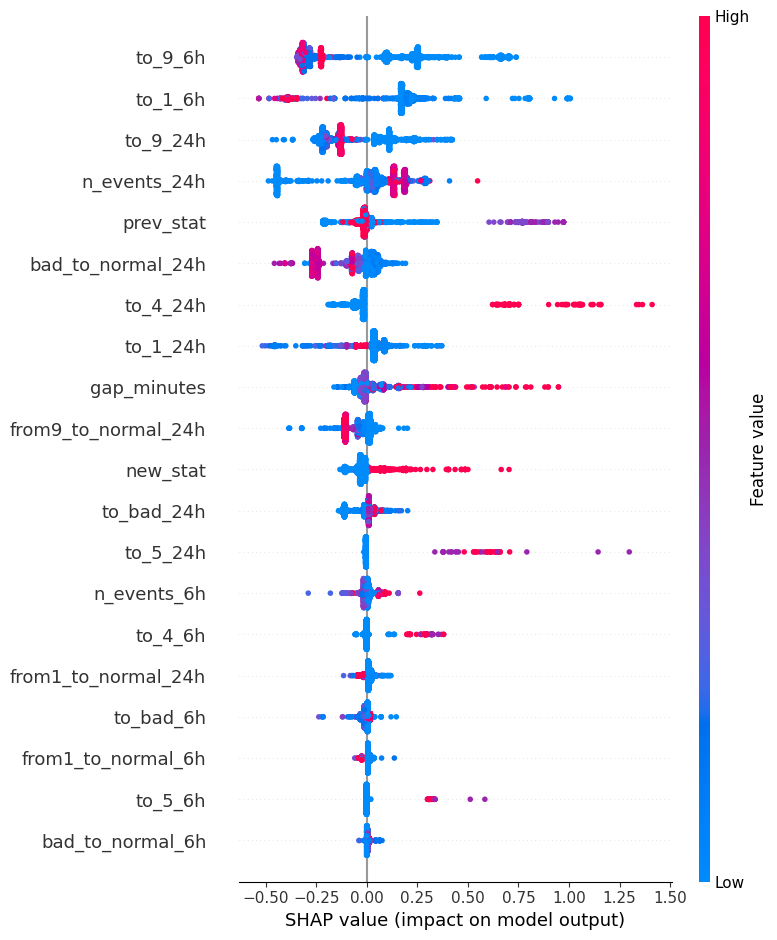

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
import shap
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# PATH / SETTINGS
# -------------------------
CSV_PATH = "/content/drive/MyDrive/KT에이블스쿨/빅프로젝트/train_csv/train_down6h_v3.csv"
TIME_COL = "event_at"
LABEL_COL = "y_down_6h"
SEED = 42
TEST_FRACTION = 0.2
GAP_HOURS = 6

LEAK_COLS = {"started_down_next6h", "down_minutes_next6h", "normal_ratio_prev6h"}

# -------------------------
# LOAD
# -------------------------
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df["charger_key"] = df["statId"].astype(str) + "_" + df["chgerId"].astype(str)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce").astype(int)
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)

print("rows:", len(df), "chargers:", df["charger_key"].nunique(), "pos_rate:", df[LABEL_COL].mean())

# -------------------------
# TIME SPLIT
# -------------------------
t_split = df[TIME_COL].quantile(1 - TEST_FRACTION)
t_gap = pd.Timedelta(hours=float(GAP_HOURS))

train_df = df[df[TIME_COL] <= (t_split - t_gap)].copy()
test_df  = df[df[TIME_COL] >  t_split].copy()

print("train:", len(train_df), "test:", len(test_df))

# -------------------------
# FEATURES
# -------------------------
drop_cols = {LABEL_COL, TIME_COL, "statId", "chgerId", "busiId", "charger_key"} | LEAK_COLS
feature_cols = [c for c in train_df.columns if c not in drop_cols and pd.api.types.is_numeric_dtype(train_df[c])]

X_train = train_df[feature_cols]
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_cols]
y_test  = test_df[LABEL_COL].values

imp = SimpleImputer(strategy="median")
X_train_imp = imp.fit_transform(X_train).astype(np.float32)
X_test_imp  = imp.transform(X_test).astype(np.float32)

# imbalance
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / max(pos, 1)

# -------------------------
# LIGHTGBM BINARY
# -------------------------
clf = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=8000,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=50,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    verbosity=-1,
)

val_frac = 0.1
val_size = max(int(len(X_train_imp) * val_frac), 1)

X_tr, y_tr = X_train_imp[:-val_size], y_train[:-val_size]
X_val, y_val = X_train_imp[-val_size:], y_train[-val_size:]

clf.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(300, verbose=False)]
)

p_test = clf.predict_proba(X_test_imp)[:, 1]

roc = roc_auc_score(y_test, p_test)
prauc = average_precision_score(y_test, p_test)

print("\n=== BASE MODEL ===")
print("ROC-AUC:", roc, "PR-AUC:", prauc)

# ============================================================
# CALIBRATION
# ============================================================

# Platt
p_val = clf.predict_proba(X_val)[:, 1]
platt = LogisticRegression(max_iter=1000)
platt.fit(p_val.reshape(-1,1), y_val)
p_test_platt = platt.predict_proba(p_test.reshape(-1,1))[:,1]

# Isotonic
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(p_val, y_val)
p_test_iso = iso.predict(p_test)

# Brier
brier_raw = brier_score_loss(y_test, p_test)
brier_platt = brier_score_loss(y_test, p_test_platt)
brier_iso = brier_score_loss(y_test, p_test_iso)

print("\n=== CALIBRATION ===")
print("raw:", brier_raw, "platt:", brier_platt, "iso:", brier_iso)

# ============================================================
# LAMBDARANK (Top-K optimization)
# ============================================================

train_group = train_df.groupby("charger_key").size().values
test_group  = test_df.groupby("charger_key").size().values

ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    n_estimators=4000,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
)

ranker.fit(
    X_train_imp, y_train,
    group=train_group,
    eval_set=[(X_test_imp, y_test)],
    eval_group=[test_group],
    eval_at=[10,50,100],
    callbacks=[lgb.early_stopping(200, verbose=False)]
)

p_test_rank = ranker.predict(X_test_imp)

def topk_recall(y, p, k):
    idx = np.argsort(-p)[:k]
    return y[idx].sum() / max(y.sum(),1)

print("\n=== TOP-K RECALL ===")
for k in [50,100,200,500]:
    print(f"k={k} | binary={topk_recall(y_test,p_test,k):.3f} | rank={topk_recall(y_test,p_test_rank,k):.3f}")

# ============================================================
# SHAP EXPLAINABILITY
# ============================================================

print("\n=== SHAP ===")

explainer = shap.TreeExplainer(clf.booster_)
sample_idx = np.random.choice(len(X_test_imp), size=min(2000,len(X_test_imp)), replace=False)
X_sample = X_test_imp[sample_idx]

shap_values = explainer.shap_values(X_sample)

# global importance
shap.summary_plot(shap_values, X_sample, feature_names=feature_cols)


# 데이터셋 선정을 위한 것. RF로 테스트

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# -------------------------
# (OPTIONAL) SHAP import guard
#   - sklearn/shap 버전 충돌이 가끔 있음
#   - 실패하면 SHAP 파트만 스킵하고 나머지 파이프라인은 정상 실행
# -------------------------
HAS_SHAP = True
try:
    import shap
except Exception as e:
    HAS_SHAP = False
    print("[WARN] SHAP import failed -> SHAP step will be skipped.")
    print("       error:", repr(e))
    print("       (Colab에서 해결 팁) `!pip -q install -U shap` 또는 sklearn/shap 버전 맞추기")

# -------------------------
# PATH / SETTINGS
# -------------------------
CSV_PATH = "/content/drive/MyDrive/KT에이블스쿨/빅프로젝트/train_csv/train_down6h_7days.csv"
TIME_COL = "event_at"
LABEL_COL = "y_down_6h"
SEED = 42
TEST_FRACTION = 0.2
GAP_HOURS = 6

# 누설/미래정보 의심 컬럼(너가 지정한 그대로)
LEAK_COLS = {"started_down_next6h", "down_minutes_next6h", "normal_ratio_prev6h"}

# -------------------------
# LOAD
# -------------------------
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")

# charger_key 생성
df["charger_key"] = df["statId"].astype(str) + "_" + df["chgerId"].astype(str)

# time/label 정리
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce").fillna(0).astype(int)

# 정렬
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)

print("rows:", len(df), "chargers:", df["charger_key"].nunique(), "pos_rate:", float(df[LABEL_COL].mean()))

# -------------------------
# TIME SPLIT (+ GAP)
# -------------------------
t_split = df[TIME_COL].quantile(1 - TEST_FRACTION)
t_gap = pd.Timedelta(hours=float(GAP_HOURS))

train_df = df[df[TIME_COL] <= (t_split - t_gap)].copy()
test_df  = df[df[TIME_COL] >  t_split].copy()

print("train:", len(train_df), "test:", len(test_df), "| split_at:", str(t_split), "| gap_hours:", GAP_HOURS)

# -------------------------
# FEATURES
# -------------------------
drop_cols = {LABEL_COL, TIME_COL, "statId", "chgerId", "busiId", "charger_key"} | set(LEAK_COLS)

# numeric만 사용(운영/배포에서 재현성 좋게)
feature_cols = [
    c for c in train_df.columns
    if (c not in drop_cols) and pd.api.types.is_numeric_dtype(train_df[c])
]

print("n_features:", len(feature_cols))

X_train = train_df[feature_cols]
y_train = train_df[LABEL_COL].values.astype(int)
X_test  = test_df[feature_cols]
y_test  = test_df[LABEL_COL].values.astype(int)

# -------------------------
# IMPUTE
# -------------------------
imp = SimpleImputer(strategy="median")
X_train_imp = imp.fit_transform(X_train).astype(np.float32)
X_test_imp  = imp.transform(X_test).astype(np.float32)

# -------------------------
# TRAIN/VAL SPLIT (chronological within train)
# -------------------------
val_frac = 0.1
val_size = max(int(len(X_train_imp) * val_frac), 1)

X_tr, y_tr   = X_train_imp[:-val_size], y_train[:-val_size]
X_val, y_val = X_train_imp[-val_size:], y_train[-val_size:]

print("train_tr:", len(X_tr), "train_val:", len(X_val))

# -------------------------
# RANDOM FOREST (BINARY)
# -------------------------
rf = RandomForestClassifier(
    n_estimators=1200,
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=-1,
)

rf.fit(X_tr, y_tr)

p_test = rf.predict_proba(X_test_imp)[:, 1]

roc = roc_auc_score(y_test, p_test) if len(np.unique(y_test)) > 1 else np.nan
prauc = average_precision_score(y_test, p_test) if y_test.sum() > 0 else np.nan

print("\n=== BASE MODEL (RF) ===")
print("ROC-AUC:", roc, "PR-AUC:", prauc)

# ============================================================
# CALIBRATION
# ============================================================

# validation probabilities (IMPORTANT: X_val는 이미 imputed numpy)
p_val = rf.predict_proba(X_val)[:, 1]

# Platt (logistic on probabilities)
platt = LogisticRegression(max_iter=2000, solver="lbfgs", random_state=SEED)
platt.fit(p_val.reshape(-1, 1), y_val)
p_test_platt = platt.predict_proba(p_test.reshape(-1, 1))[:, 1]

# Isotonic
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(p_val, y_val)
p_test_iso = iso.predict(p_test)

# Brier
brier_raw   = brier_score_loss(y_test, p_test)
brier_platt = brier_score_loss(y_test, p_test_platt)
brier_iso   = brier_score_loss(y_test, p_test_iso)

print("\n=== CALIBRATION (RF) ===")
print("brier(raw)  :", brier_raw)
print("brier(platt):", brier_platt)
print("brier(iso)  :", brier_iso)

# ============================================================
# "TOP-K OPTIMIZATION" SURROGATE
# - RFClassifier 확률 vs RFRegressor score 를 Top-K에서 비교
# ============================================================

rf_rank = RandomForestRegressor(
    n_estimators=1200,
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    bootstrap=True,
    random_state=SEED,
    n_jobs=-1,
)

rf_rank.fit(X_train_imp, y_train.astype(np.float32))
p_test_rank = rf_rank.predict(X_test_imp)  # ranking score

def topk_recall(y, p, k):
    k = int(min(k, len(p)))
    idx = np.argsort(-p)[:k]
    denom = max(int(y.sum()), 1)
    return float(y[idx].sum()) / denom

print("\n=== TOP-K RECALL (RF) ===")
for k in [50, 100, 200, 500]:
    print(
        f"k={k:>3d} | rf_prob={topk_recall(y_test, p_test, k):.3f}"
        f" | platt={topk_recall(y_test, p_test_platt, k):.3f}"
        f" | iso={topk_recall(y_test, p_test_iso, k):.3f}"
        f" | rf_rank_score={topk_recall(y_test, p_test_rank, k):.3f}"
    )

# ============================================================
# SHAP EXPLAINABILITY
# ============================================================

if HAS_SHAP:
    print("\n=== SHAP (RF) ===")

    # 샘플링 (속도/메모리 절약)
    rng = np.random.default_rng(SEED)
    sample_n = min(2000, len(X_test_imp))
    sample_idx = rng.choice(len(X_test_imp), size=sample_n, replace=False)
    X_sample = X_test_imp[sample_idx]

    # TreeExplainer
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_sample)

    # binary classifier일 때 보통 [neg_class, pos_class]
    if isinstance(shap_values, list) and len(shap_values) == 2:
        shap.summary_plot(shap_values[1], X_sample, feature_names=feature_cols)
    else:
        shap.summary_plot(shap_values, X_sample, feature_names=feature_cols)
else:
    print("\n=== SHAP SKIPPED === (import 실패)")


[WARN] SHAP import failed -> SHAP step will be skipped.
       error: ImportError("cannot import name '_randomized_svd' from 'sklearn.utils.extmath' (/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py)")
       (Colab에서 해결 팁) `!pip -q install -U shap` 또는 sklearn/shap 버전 맞추기
rows: 419451 chargers: 47574 pos_rate: 0.0414494184064408
train: 325683 test: 83637 | split_at: 2026-01-24 22:10:01 | gap_hours: 6
n_features: 21
train_tr: 293115 train_val: 32568

=== BASE MODEL (RF) ===
ROC-AUC: 0.9845038578631661 PR-AUC: 0.7739432476391307

=== CALIBRATION (RF) ===
brier(raw)  : 0.02260195510478372
brier(platt): 0.02303746085443352
brier(iso)  : 0.019725288038076248

=== TOP-K RECALL (RF) ===
k= 50 | rf_prob=0.010 | platt=0.010 | iso=0.010 | rf_rank_score=0.010
k=100 | rf_prob=0.019 | platt=0.019 | iso=0.019 | rf_rank_score=0.019
k=200 | rf_prob=0.038 | platt=0.038 | iso=0.038 | rf_rank_score=0.038
k=500 | rf_prob=0.096 | platt=0.096 | iso=0.095 | rf_rank_score=0.096

=== SHAP SKIPP

# 모델 선정(RF vs LGBM vs XGBoost)

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# PATH / SETTINGS
# -------------------------
CSV_PATH = "/content/drive/MyDrive/KT에이블스쿨/빅프로젝트/train_csv/train_down6h_v3.csv"
TIME_COL = "event_at"
LABEL_COL = "y_down_6h"
SEED = 42
TEST_FRACTION = 0.2
GAP_HOURS = 6

LEAK_COLS = {"started_down_next6h", "down_minutes_next6h", "normal_ratio_prev6h"}

# -------------------------
# LOAD & SPLIT
# -------------------------
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df["charger_key"] = df["statId"].astype(str) + "_" + df["chgerId"].astype(str)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce").astype(int)
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)

t_split = df[TIME_COL].quantile(1 - TEST_FRACTION)
t_gap = pd.Timedelta(hours=float(GAP_HOURS))

train_df = df[df[TIME_COL] <= (t_split - t_gap)].copy()
test_df  = df[df[TIME_COL] >  t_split].copy()

# -------------------------
# FEATURES (UNCHANGED)
# -------------------------
drop_cols = {LABEL_COL, TIME_COL, "statId", "chgerId", "busiId", "charger_key"} | LEAK_COLS
feature_cols = [c for c in train_df.columns if c not in drop_cols and pd.api.types.is_numeric_dtype(train_df[c])]

X_train = train_df[feature_cols]
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_cols]
y_test  = test_df[LABEL_COL].values

imp = SimpleImputer(strategy="median")
X_train_imp = imp.fit_transform(X_train).astype(np.float32)
X_test_imp  = imp.transform(X_test).astype(np.float32)

# imbalance
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / max(pos, 1)

print("Train:", len(X_train_imp), "Test:", len(X_test_imp), "Pos rate:", y_train.mean())

# ============================================================
# MODEL LIST
# ============================================================

models = {

    # Random Forest
    "RF": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=SEED,
    ),

    # XGBoost
    "XGB": XGBClassifier(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        tree_method="hist",
        eval_metric="auc",
        random_state=SEED,
        n_jobs=-1,
    ),

    # LightGBM baseline
    "LGBM": lgb.LGBMClassifier(
        objective="binary",
        n_estimators=2000,
        learning_rate=0.05,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=50,
        scale_pos_weight=scale_pos_weight,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    ),

    # LightGBM tuned
    "LGBM_TUNED": lgb.LGBMClassifier(
        objective="binary",
        n_estimators=4000,
        learning_rate=0.03,
        num_leaves=96,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=30,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    ),
}

# ============================================================
# TRAIN & EVAL
# ============================================================

results = []

for name, model in models.items():
    print(f"\n=== TRAINING: {name} ===")

    model.fit(X_train_imp, y_train)

    p_test = model.predict_proba(X_test_imp)[:, 1]

    roc = roc_auc_score(y_test, p_test)
    pr  = average_precision_score(y_test, p_test)

    # Top-K recall (운영 지표)
    def topk_recall(y, p, k):
        idx = np.argsort(-p)[:k]
        return y[idx].sum() / max(y.sum(), 1)

    r100 = topk_recall(y_test, p_test, 100)
    r500 = topk_recall(y_test, p_test, 500)

    print(f"ROC-AUC={roc:.4f} | PR-AUC={pr:.4f} | R@100={r100:.3f} | R@500={r500:.3f}")

    results.append([name, roc, pr, r100, r500])

# ============================================================
# RESULT TABLE
# ============================================================

res_df = pd.DataFrame(results, columns=["Model", "ROC-AUC", "PR-AUC", "Recall@100", "Recall@500"])
res_df = res_df.sort_values("PR-AUC", ascending=False)

print("\n=== FINAL COMPARISON ===")
print(res_df.to_string(index=False))


Train: 93422 Test: 25747 Pos rate: 0.01937445141401383

=== TRAINING: RF ===
ROC-AUC=0.9868 | PR-AUC=0.8420 | R@100=0.301 | R@500=0.833

=== TRAINING: XGB ===
ROC-AUC=0.9823 | PR-AUC=0.8188 | R@100=0.301 | R@500=0.772

=== TRAINING: LGBM ===
ROC-AUC=0.9747 | PR-AUC=0.7720 | R@100=0.298 | R@500=0.757

=== TRAINING: LGBM_TUNED ===
ROC-AUC=0.9756 | PR-AUC=0.7724 | R@100=0.298 | R@500=0.769

=== FINAL COMPARISON ===
     Model  ROC-AUC   PR-AUC  Recall@100  Recall@500
        RF 0.986760 0.842044    0.300912    0.832827
       XGB 0.982350 0.818768    0.300912    0.772036
LGBM_TUNED 0.975568 0.772400    0.297872    0.768997
      LGBM 0.974667 0.772015    0.297872    0.756839


# Validation

rows: 129039 chargers: 26178 pos_rate: 0.01758383124481746

=== ROLLING TIME BACKTEST ===


100%|██████████| 5/5 [01:07<00:00, 13.52s/it]


ROC-AUC mean: 0.9851866688088012
PR-AUC  mean: 0.839460013436882

=== CHARGER HOLD-OUT ===
ROC-AUC: 0.9941668897721578
PR-AUC : 0.8964552224146267


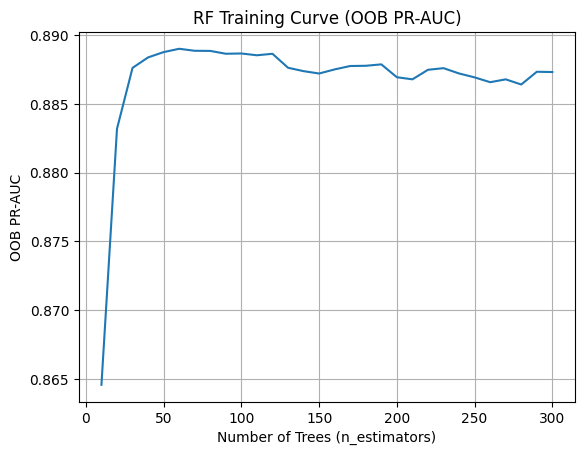

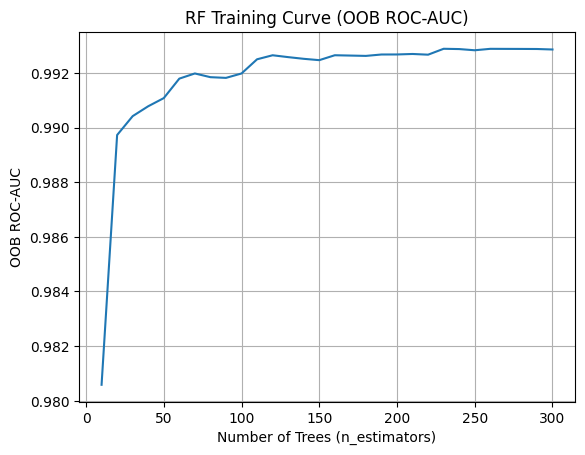


=== CALIBRATION ===
Brier raw : 0.006347453784792091
Brier platt: 0.007751514926742081
Brier iso : 0.006688298667825192

=== TOP-K RECALL ===
k=50 | raw=0.085 | platt=0.085
k=100 | raw=0.168 | platt=0.168
k=200 | raw=0.337 | platt=0.337
k=500 | raw=0.731 | platt=0.731


In [ ]:
!pip install -q --upgrade "scikit-learn==1.8.0"
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# PATH / SETTINGS
# -------------------------
CSV_PATH = "/content/drive/MyDrive/KT에이블스쿨/빅프로젝트/train_csv/train_down6h_v3.csv"
TIME_COL = "event_at"
LABEL_COL = "y_down_6h"
SEED = 42
TEST_FRACTION = 0.2
GAP_HOURS = 6
ROLLING_SPLITS = 5

LEAK_COLS = {"started_down_next6h", "down_minutes_next6h", "normal_ratio_prev6h"}

# -------------------------
# LOAD
# -------------------------
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df["charger_key"] = df["statId"].astype(str) + "_" + df["chgerId"].astype(str)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce").astype(int)
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)

# -------------------------
# FEATURE SET (고정)
# -------------------------
drop_cols = {LABEL_COL, TIME_COL, "statId", "chgerId", "busiId", "charger_key"} | LEAK_COLS
feature_cols = [c for c in df.columns if c not in drop_cols and pd.api.types.is_numeric_dtype(df[c])]

print("rows:", len(df), "chargers:", df["charger_key"].nunique(), "pos_rate:", df[LABEL_COL].mean())

# ============================================================
# 1️⃣ ROLLING TIME BACKTEST
# ============================================================

print("\n=== ROLLING TIME BACKTEST ===")

times = df[TIME_COL].quantile(np.linspace(0.5, 0.9, ROLLING_SPLITS))

rolling_results = []

for t_split in tqdm(times):

    train_df = df[df[TIME_COL] <= (t_split - pd.Timedelta(hours=GAP_HOURS))]
    test_df  = df[df[TIME_COL] > t_split]

    if len(test_df) < 1000:
        continue

    X_train = train_df[feature_cols]
    y_train = train_df[LABEL_COL].values
    X_test  = test_df[feature_cols]
    y_test  = test_df[LABEL_COL].values

    imp = SimpleImputer(strategy="median")
    X_train = imp.fit_transform(X_train)
    X_test  = imp.transform(X_test)

    model = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=SEED,
    )
    model.fit(X_train, y_train)

    p = model.predict_proba(X_test)[:,1]

    roc = roc_auc_score(y_test, p)
    pr  = average_precision_score(y_test, p)

    rolling_results.append((roc, pr))

rolling_results = np.array(rolling_results)

print("ROC-AUC mean:", rolling_results[:,0].mean())
print("PR-AUC  mean:", rolling_results[:,1].mean())

# ============================================================
# 2️⃣ CHARGER HOLD-OUT VALIDATION
# ============================================================

print("\n=== CHARGER HOLD-OUT ===")

chargers = df["charger_key"].unique()
np.random.seed(SEED)
test_ch = np.random.choice(chargers, size=int(len(chargers)*TEST_FRACTION), replace=False)

train_df = df[~df["charger_key"].isin(test_ch)]
test_df  = df[df["charger_key"].isin(test_ch)]

X_train = train_df[feature_cols]
y_train = train_df[LABEL_COL].values
X_test  = test_df[feature_cols]
y_test  = test_df[LABEL_COL].values

imp = SimpleImputer(strategy="median")
X_train = imp.fit_transform(X_train)
X_test  = imp.transform(X_test)

model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=SEED,
)
model.fit(X_train, y_train)

p = model.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, p))
print("PR-AUC :", average_precision_score(y_test, p))

# ============================================================
# 2.5) RF "Training Curve" 대안: OOB PR-AUC / ROC-AUC curve
# - RF는 loss curve가 없어서 OOB 성능 안정화 곡선으로 대체
# ============================================================

import matplotlib.pyplot as plt

rf_oob = RandomForestClassifier(
    n_estimators=10,          # warm_start라서 시작값 필요
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=SEED,
    oob_score=True,
    bootstrap=True,
    warm_start=True,
)

oob_pr, oob_roc = [], []
steps = list(range(10, 301, 10))

for n in steps:
    rf_oob.set_params(n_estimators=n)
    rf_oob.fit(X_train, y_train)   # ✅ charger hold-out train set 사용 (고정)

    p_oob = rf_oob.oob_decision_function_[:, 1]
    oob_roc.append(roc_auc_score(y_train, p_oob))
    oob_pr.append(average_precision_score(y_train, p_oob))

plt.figure()
plt.plot(steps, oob_pr)
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("OOB PR-AUC")
plt.title("RF Training Curve (OOB PR-AUC)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(steps, oob_roc)
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("OOB ROC-AUC")
plt.title("RF Training Curve (OOB ROC-AUC)")
plt.grid(True)
plt.show()


# ============================================================
# 3️⃣ CALIBRATION (RF 기준)
# ============================================================

print("\n=== CALIBRATION ===")

# val split (train 끝 10%)
val_size = int(len(X_train)*0.1)
X_tr, y_tr = X_train[:-val_size], y_train[:-val_size]
X_val, y_val = X_train[-val_size:], y_train[-val_size:]

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=SEED)
rf.fit(X_tr, y_tr)

p_val = rf.predict_proba(X_val)[:,1]
p_test = rf.predict_proba(X_test)[:,1]

# Platt
platt = LogisticRegression(max_iter=1000)
platt.fit(p_val.reshape(-1,1), y_val)
p_test_platt = platt.predict_proba(p_test.reshape(-1,1))[:,1]

# Isotonic
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(p_val, y_val)
p_test_iso = iso.predict(p_test)

print("Brier raw :", brier_score_loss(y_test, p_test))
print("Brier platt:", brier_score_loss(y_test, p_test_platt))
print("Brier iso :", brier_score_loss(y_test, p_test_iso))

# ============================================================
# 4️⃣ TOP-K OPERATION METRIC
# ============================================================

print("\n=== TOP-K RECALL ===")

def topk(y, p, k):
    idx = np.argsort(-p)[:k]
    return y[idx].sum() / max(y.sum(),1)

for k in [50,100,200,500]:
    print(f"k={k} | raw={topk(y_test,p_test,k):.3f} | platt={topk(y_test,p_test_platt,k):.3f}")

# 모델 저장

In [ ]:

import os, joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

# =========================
# PATH (RF 번들 파일명만 바꿔서 저장)
# =========================
SAVE_DIR = "/content/drive/MyDrive/KT에이블스쿨/빅프로젝트/model"
os.makedirs(SAVE_DIR, exist_ok=True)
ARTIFACT_PATH = os.path.join(SAVE_DIR, "rf_risk_model_bundle.joblib")

def save_bundle(imp, feature_cols, base_model, calibrator=None, path=ARTIFACT_PATH, version="rf_v1"):
    bundle = {
        "imputer": imp,
        "feature_cols": list(feature_cols),
        "base_model": base_model,
        "calibrator": calibrator,   #  RF는 보통 None 권장
        "version": version
    }
    joblib.dump(bundle, path, compress=3)
    print("✅ Saved:", path)
    print("  - n_features:", len(feature_cols))
    print("  - has_calibrator:", calibrator is not None)

def load_bundle(path=ARTIFACT_PATH):
    bundle = joblib.load(path)
    print("✅ Loaded:", path)
    print("  - n_features:", len(bundle["feature_cols"]))
    print("  - has_calibrator:", bundle.get("calibrator") is not None)
    print("  - model:", type(bundle["base_model"]).__name__)
    return bundle

def predict_proba_bundle(df_in: pd.DataFrame, bundle: dict):
    imp = bundle["imputer"]
    feature_cols = bundle["feature_cols"]
    base_model = bundle["base_model"]
    calibrator = bundle.get("calibrator", None)

    missing = [c for c in feature_cols if c not in df_in.columns]
    if missing:
        raise ValueError(f"Missing feature columns: {missing[:20]} ... total={len(missing)}")

    X = df_in[feature_cols].copy()
    X_imp = imp.transform(X)  # RF는 float32 강제 안 해도 됨

    p_raw = base_model.predict_proba(X_imp)[:, 1]
    p_cal = calibrator.predict_proba(p_raw.reshape(-1, 1))[:, 1] if calibrator is not None else None
    return p_raw, p_cal

def aggregate_charger_scores(df_pred: pd.DataFrame, p_col: str, time_col="event_at"):
    g = df_pred.sort_values(time_col).groupby("charger_key", as_index=False)
    return g.agg(
        p_max=(p_col, "max"),
        p_last=(p_col, "last"),
        last_time=(time_col, "last"),
    )

# (1) imputer fit + train matrix
imp_rf = SimpleImputer(strategy="median")
X_train_rf = imp_rf.fit_transform(train_df[feature_cols])
y_train_rf = train_df[LABEL_COL].values

# (2) RF 학습 (너가 쓰던 파라미터)
rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
)
rf_model.fit(X_train_rf, y_train_rf)

# (3) calibration은 지금 결과상 추천 안 함 -> None
calibrator = None

# (4) 저장
save_bundle(imp_rf, feature_cols, rf_model, calibrator=calibrator)

bundle = load_bundle()

df_new = test_df.copy()
df_new["charger_key"] = df_new["statId"].astype(str) + "_" + df_new["chgerId"].astype(str)
df_new["event_at"] = pd.to_datetime(df_new["event_at"], errors="coerce")

p_raw, p_cal = predict_proba_bundle(df_new, bundle)
df_new["p_raw"] = p_raw
df_new["p"] = p_raw if p_cal is None else p_cal

charger_scores = aggregate_charger_scores(df_new, p_col="p", time_col="event_at")
print("\nTop 20 chargers by p_max:")
print(charger_scores.sort_values("p_max", ascending=False).head(20))


✅ Saved: /content/drive/MyDrive/KT에이블스쿨/빅프로젝트/model/rf_risk_model_bundle.joblib
  - n_features: 21
  - has_calibrator: False
✅ Loaded: /content/drive/MyDrive/KT에이블스쿨/빅프로젝트/model/rf_risk_model_bundle.joblib
  - n_features: 21
  - has_calibrator: False
  - model: RandomForestClassifier

Top 20 chargers by p_max:
      charger_key     p_max    p_last           last_time
2785   KP003976_1  0.999030  0.489320 2026-01-16 04:46:02
2758   KE001024_1  0.999006  0.981808 2026-01-14 13:36:02
2709   JA260015_2  0.998915  0.994912 2026-01-16 00:36:02
1308   EP210161_5  0.998862  0.983066 2026-01-15 10:46:02
1327   EP541400_1  0.998853  0.998827 2026-01-16 02:26:02
1318   EP240029_1  0.998828  0.605608 2026-01-15 11:16:02
1321   EP240050_4  0.998827  0.998736 2026-01-16 07:36:02
1320  EP240048_12  0.998827  0.998168 2026-01-14 00:16:02
1297   EH213173_2  0.998827  0.998827 2026-01-16 03:36:02
1319  EP240046_13  0.998827  0.998827 2026-01-14 14:46:02
9      AM900024_7  0.9